In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Calculate the date range (5 years from today)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Download the data
mstr = yf.download('MSTR', start=start_date, end=end_date)
btc = yf.download('BTC-USD', start=start_date, end=end_date)

# Align BTC prices with MSTR trading days
# Keep only the dates where MSTR was traded
btc = btc.reindex(mstr.index)

# Calculate daily returns
mstr['Daily_Return'] = mstr['Adj Close'].pct_change()
btc['Daily_Return'] = btc['Adj Close'].pct_change()

# Calculate annual volatility (standard deviation of daily returns * sqrt(252))
mstr_volatility = mstr['Daily_Return'].std() * np.sqrt(252)
btc_volatility = btc['Daily_Return'].std() * np.sqrt(252)

# Print results
print(f"Number of trading days: {len(mstr)}")
print(f"MSTR Annual Volatility: {mstr_volatility:.2%}")
print(f"BTC Annual Volatility: {btc_volatility:.2%}")

# Create a DataFrame with both return series
returns_df = pd.DataFrame({
    'MSTR_Returns': mstr['Daily_Return'],
    'BTC_Returns': btc['Daily_Return']
})

# Print first few rows to verify alignment
print("\nFirst few rows of aligned returns:")
print(returns_df.head())

# Calculate correlation between returns
correlation = returns_df.corr()
print("\nCorrelation between MSTR and BTC returns:")
print(correlation)

# Optional: Save aligned returns to CSV
returns_df.to_csv('aligned_returns.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Number of trading days: 1257
MSTR Annual Volatility: 91.32%
BTC Annual Volatility: 64.86%

First few rows of aligned returns:
            MSTR_Returns  BTC_Returns
Date                                 
2019-11-26           NaN          NaN
2019-11-27      0.001444     0.043402
2019-11-29     -0.015005     0.030482
2019-12-02     -0.001663    -0.056596
2019-12-03     -0.000666    -0.000252

Correlation between MSTR and BTC returns:
              MSTR_Returns  BTC_Returns
MSTR_Returns      1.000000     0.646346
BTC_Returns       0.646346     1.000000


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Cointegration test p-value: 0.6837
Null hypothesis: Series are not cointegrated
Series are not cointegrated at 5% significance level

Additional Statistics:
Correlation coefficient: 0.6463

Cointegrating Relationship:
Beta coefficient: 0.3619
R-squared: 0.9749


C:\Users\zzyz_\AppData\Local\Temp\ipykernel_90896\3230236537.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Beta coefficient: {model.params[0]:.4f}")


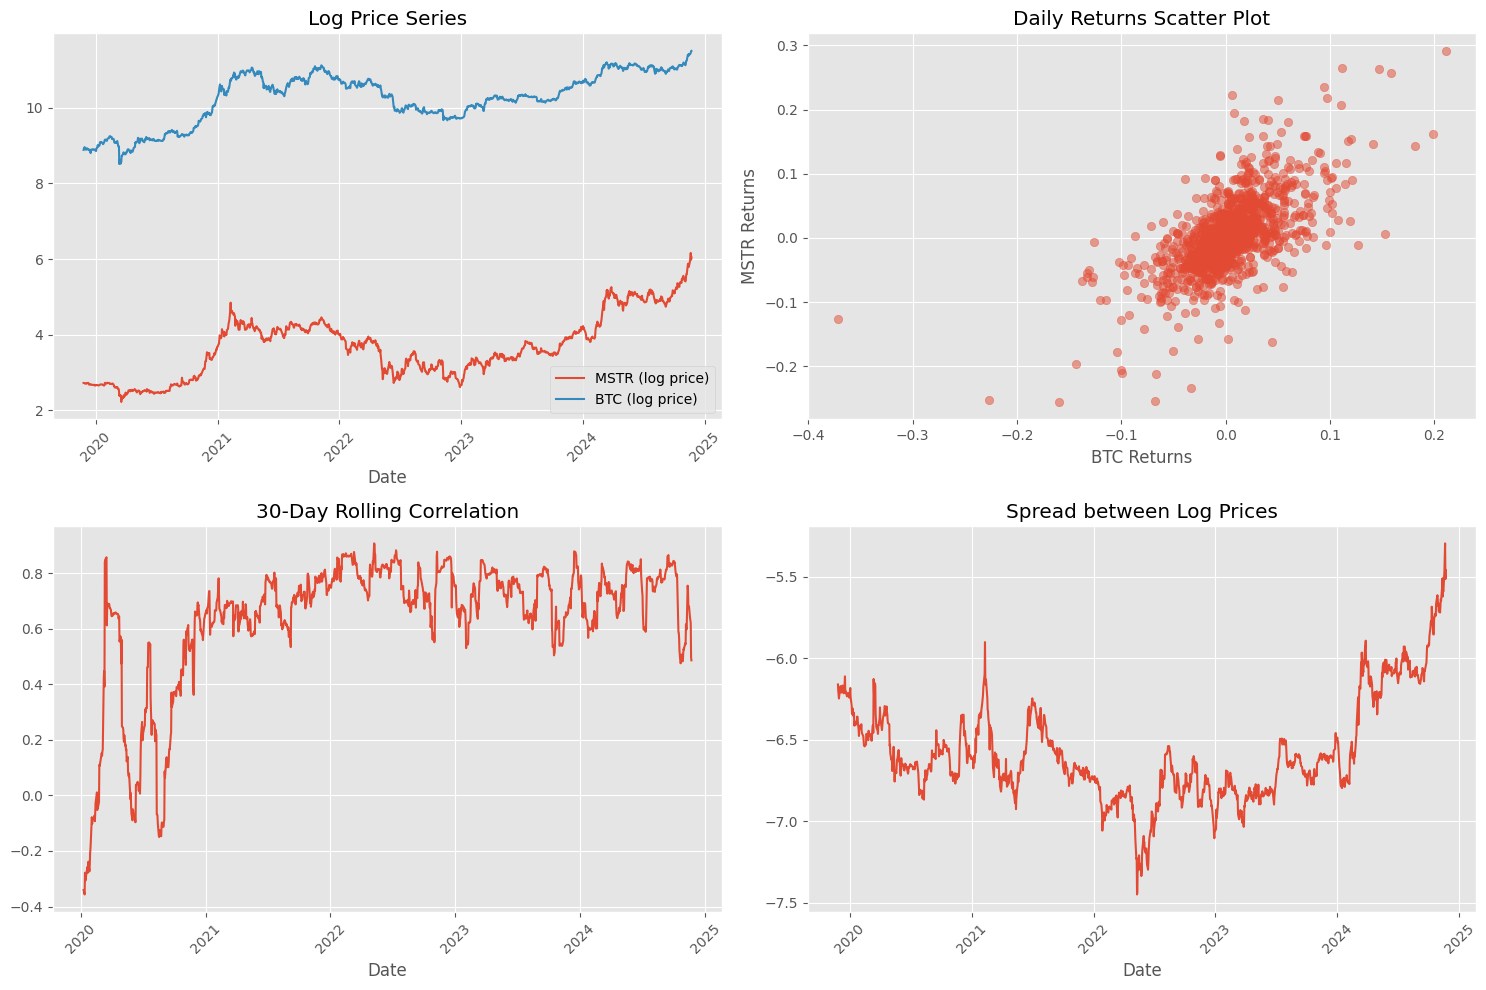

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS

# Download and prepare data (keeping previous code)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Download the data
mstr = yf.download('MSTR', start=start_date, end=end_date)
btc = yf.download('BTC-USD', start=start_date, end=end_date)

# Align BTC prices with MSTR trading days
btc = btc.reindex(mstr.index)

# Create price series (using log prices for better statistical properties)
prices_df = pd.DataFrame({
    'MSTR': np.log(mstr['Adj Close']),
    'BTC': np.log(btc['Adj Close'])
})

# Calculate returns
returns_df = pd.DataFrame({
    'MSTR': mstr['Adj Close'].pct_change(),
    'BTC': btc['Adj Close'].pct_change()
})

# Cointegration test
score, pvalue, _ = coint(prices_df['MSTR'], prices_df['BTC'])

# Create visualizations
plt.style.use('ggplot')  # Changed from 'seaborn' to 'ggplot'
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Price Series Plot
axes[0,0].plot(prices_df.index, prices_df['MSTR'], label='MSTR (log price)')
axes[0,0].plot(prices_df.index, prices_df['BTC'], label='BTC (log price)')
axes[0,0].set_title('Log Price Series')
axes[0,0].legend()
axes[0,0].set_xlabel('Date')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Returns Scatter Plot
axes[0,1].scatter(returns_df['BTC'], returns_df['MSTR'], alpha=0.5)
axes[0,1].set_title('Daily Returns Scatter Plot')
axes[0,1].set_xlabel('BTC Returns')
axes[0,1].set_ylabel('MSTR Returns')

# 3. Rolling Correlation
rolling_corr = returns_df.rolling(window=30).corr().unstack()['MSTR']['BTC']
axes[1,0].plot(rolling_corr.index, rolling_corr.values)
axes[1,0].set_title('30-Day Rolling Correlation')
axes[1,0].set_xlabel('Date')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Spread between log prices
spread = prices_df['MSTR'] - prices_df['BTC']
axes[1,1].plot(spread.index, spread.values)
axes[1,1].set_title('Spread between Log Prices')
axes[1,1].set_xlabel('Date')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()

# Print statistical results
print(f"Cointegration test p-value: {pvalue:.4f}")
print("Null hypothesis: Series are not cointegrated")
print(f"Series are {'not ' if pvalue > 0.05 else ''}cointegrated at 5% significance level")

# Calculate and print additional statistics
print("\nAdditional Statistics:")
print(f"Correlation coefficient: {returns_df.corr().iloc[0,1]:.4f}")

# Fit OLS regression for the cointegrating relationship
model = OLS(prices_df['MSTR'], prices_df['BTC']).fit()
print("\nCointegrating Relationship:")
print(f"Beta coefficient: {model.params[0]:.4f}")
print(f"R-squared: {model.rsquared:.4f}")

# Save the plot
plt.savefig('cointegration_analysis.png')
plt.show()

# Optional: Save results to CSV
results_df = pd.DataFrame({
    'Log_Prices_MSTR': prices_df['MSTR'],
    'Log_Prices_BTC': prices_df['BTC'],
    'Returns_MSTR': returns_df['MSTR'],
    'Returns_BTC': returns_df['BTC'],
    'Spread': spread,
    'Rolling_Correlation': rolling_corr
})
results_df.to_csv('cointegration_results.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Total Return: 88.25%
Annual Return: 13.52%
Sharpe Ratio: 1.14
Maximum Drawdown: -7.21%

Trading Statistics:
Number of trades: 103
Average position size: 0.044
Average correlation: 0.648


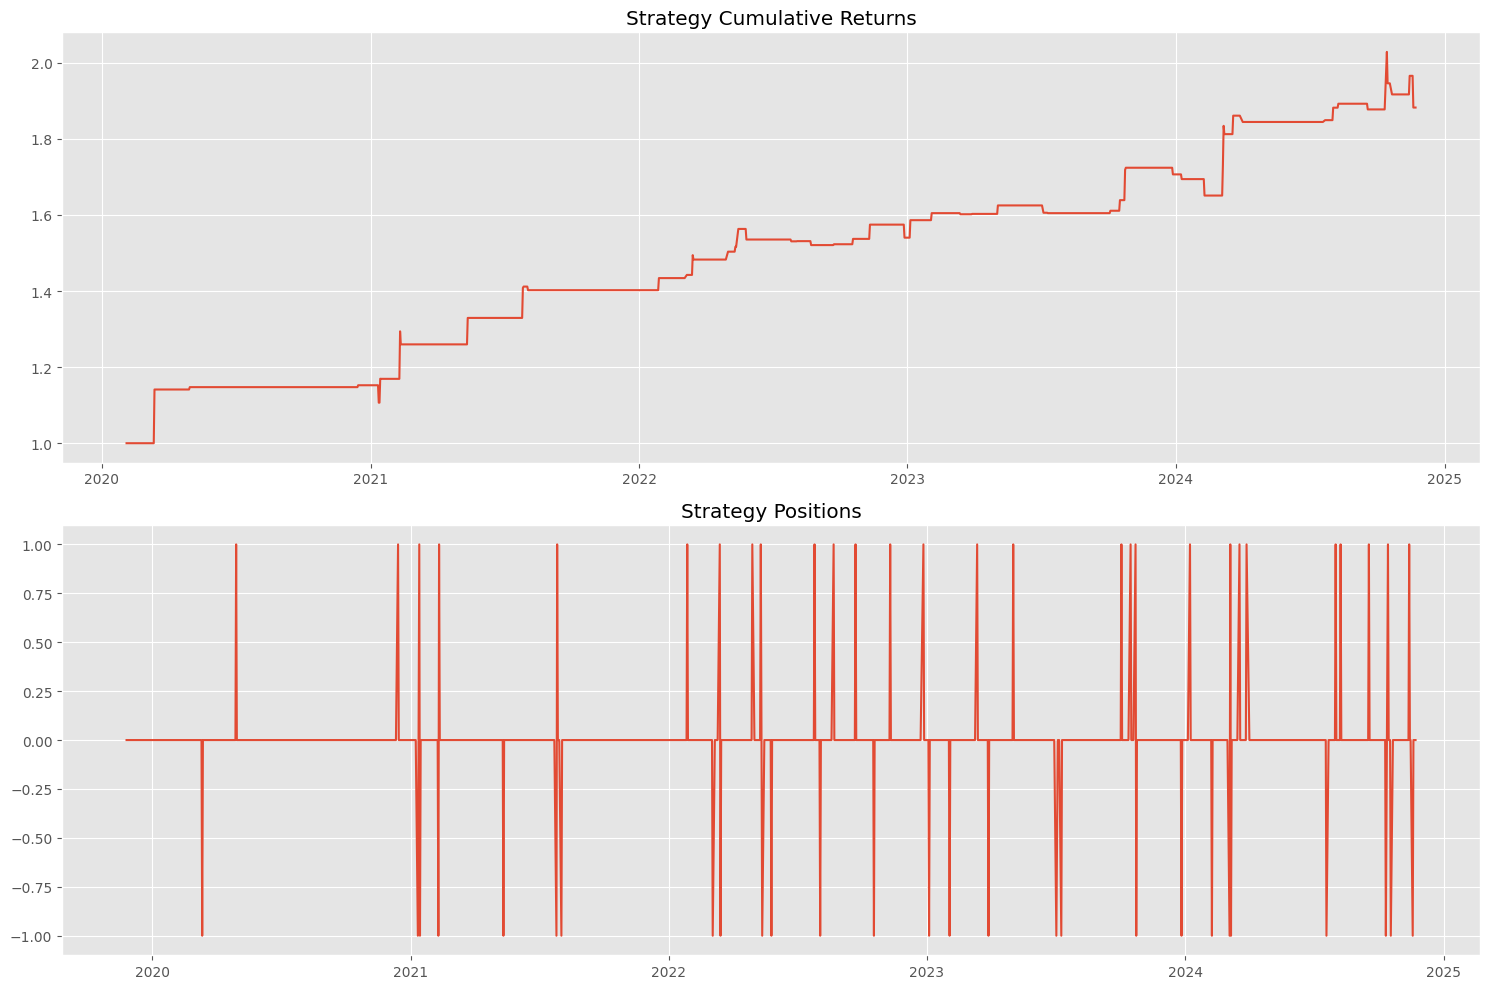

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

class PairsTrader:
    def __init__(self, z_score_window=45, z_score_threshold=2, correlation_threshold=0.6,
                 max_position=1, stop_loss=0.15, vol_ratio=1.4):
        self.z_score_window = z_score_window
        self.z_score_threshold = z_score_threshold
        self.correlation_threshold = correlation_threshold
        self.max_position = max_position
        self.stop_loss = stop_loss
        self.vol_ratio = vol_ratio  # MSTR vol / BTC vol
        
    def calculate_signals(self, returns_df):
        # Volatility-adjusted returns difference
        # Scale BTC returns by vol_ratio to make them comparable to MSTR returns
        vol_adjusted_diff = returns_df['MSTR'] - (self.vol_ratio * returns_df['BTC'])
        
        # Calculate z-score using volatility-adjusted differences
        rolling_mean = vol_adjusted_diff.rolling(window=self.z_score_window).mean()
        rolling_std = vol_adjusted_diff.rolling(window=self.z_score_window).std()
        z_score = (vol_adjusted_diff - rolling_mean) / rolling_std
        
        # Calculate rolling correlation
        rolling_corr = returns_df.rolling(window=self.z_score_window).corr().unstack()['MSTR']['BTC']
        
        signals = pd.DataFrame(index=returns_df.index)
        signals['z_score'] = z_score
        signals['correlation'] = rolling_corr
        signals['position'] = 0
        
        # Generate positions based on volatility-adjusted z-score
        signals.loc[z_score < -self.z_score_threshold, 'position'] = 1
        signals.loc[z_score > self.z_score_threshold, 'position'] = -1
        signals.loc[rolling_corr < self.correlation_threshold, 'position'] = 0
        signals.loc[abs(z_score) < 0.5, 'position'] = 0
        
        return signals
    
    def backtest(self, returns_df):
        signals = self.calculate_signals(returns_df)
        
        # Calculate base position sizes
        position_sizes = signals['z_score'].abs() / signals['z_score'].abs().max()
        position_sizes = position_sizes * self.max_position
        position_sizes = position_sizes * signals['position']
        
        # Adjust position sizes for volatility ratio
        # For MSTR positions
        mstr_position = position_sizes
        # For BTC positions (scaled by volatility ratio)
        btc_position = position_sizes * self.vol_ratio
        
        # Calculate strategy returns with volatility-adjusted positions
        strategy_returns = pd.DataFrame(index=returns_df.index)
        strategy_returns['MSTR_return'] = mstr_position.shift(1) * returns_df['MSTR']
        strategy_returns['BTC_return'] = -btc_position.shift(1) * returns_df['BTC']
        strategy_returns['total_return'] = strategy_returns['MSTR_return'] + strategy_returns['BTC_return']
        
        # Apply stop loss
        stop_loss_mask = (strategy_returns['total_return'].abs() > self.stop_loss)
        strategy_returns.loc[stop_loss_mask, 'total_return'] = -self.stop_loss
        
        strategy_returns['cumulative_return'] = (1 + strategy_returns['total_return']).cumprod()
        
        return strategy_returns, signals

# Download and prepare data
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

mstr = yf.download('MSTR', start=start_date, end=end_date)
btc = yf.download('BTC-USD', start=start_date, end=end_date)
btc = btc.reindex(mstr.index)

returns_df = pd.DataFrame({
    'MSTR': mstr['Adj Close'].pct_change(),
    'BTC': btc['Adj Close'].pct_change()
})

# Initialize and run backtest
trader = PairsTrader(vol_ratio=1.4)
strategy_returns, signals = trader.backtest(returns_df)

# Calculate performance metrics
total_return = strategy_returns['cumulative_return'].iloc[-1] - 1
annual_return = (1 + total_return) ** (252 / len(strategy_returns)) - 1
sharpe_ratio = np.sqrt(252) * strategy_returns['total_return'].mean() / strategy_returns['total_return'].std()
max_drawdown = (strategy_returns['cumulative_return'] / strategy_returns['cumulative_return'].cummax() - 1).min()

# Plot results
plt.figure(figsize=(15, 10))

# Plot 1: Cumulative Returns
plt.subplot(2, 1, 1)
plt.plot(strategy_returns['cumulative_return'])
plt.title('Strategy Cumulative Returns')
plt.grid(True)

# Plot 2: Positions
plt.subplot(2, 1, 2)
plt.plot(signals['position'])
plt.title('Strategy Positions')
plt.grid(True)

plt.tight_layout()

# Print performance metrics
print(f"Total Return: {total_return:.2%}")
print(f"Annual Return: {annual_return:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")

# Additional statistics
print("\nTrading Statistics:")
print(f"Number of trades: {(signals['position'].diff() != 0).sum()}")
print(f"Average position size: {abs(signals['position']).mean():.3f}")
print(f"Average correlation: {signals['correlation'].mean():.3f}")

# Save results to CSV
results_df = pd.DataFrame({
    'Positions': signals['position'],
    'Z_Score': signals['z_score'],
    'Correlation': signals['correlation'],
    'Strategy_Returns': strategy_returns['total_return'],
    'Cumulative_Returns': strategy_returns['cumulative_return']
})
results_df.to_csv('backtest_results.csv')

plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Number of trades: 57
Average holding period: 21.7 days


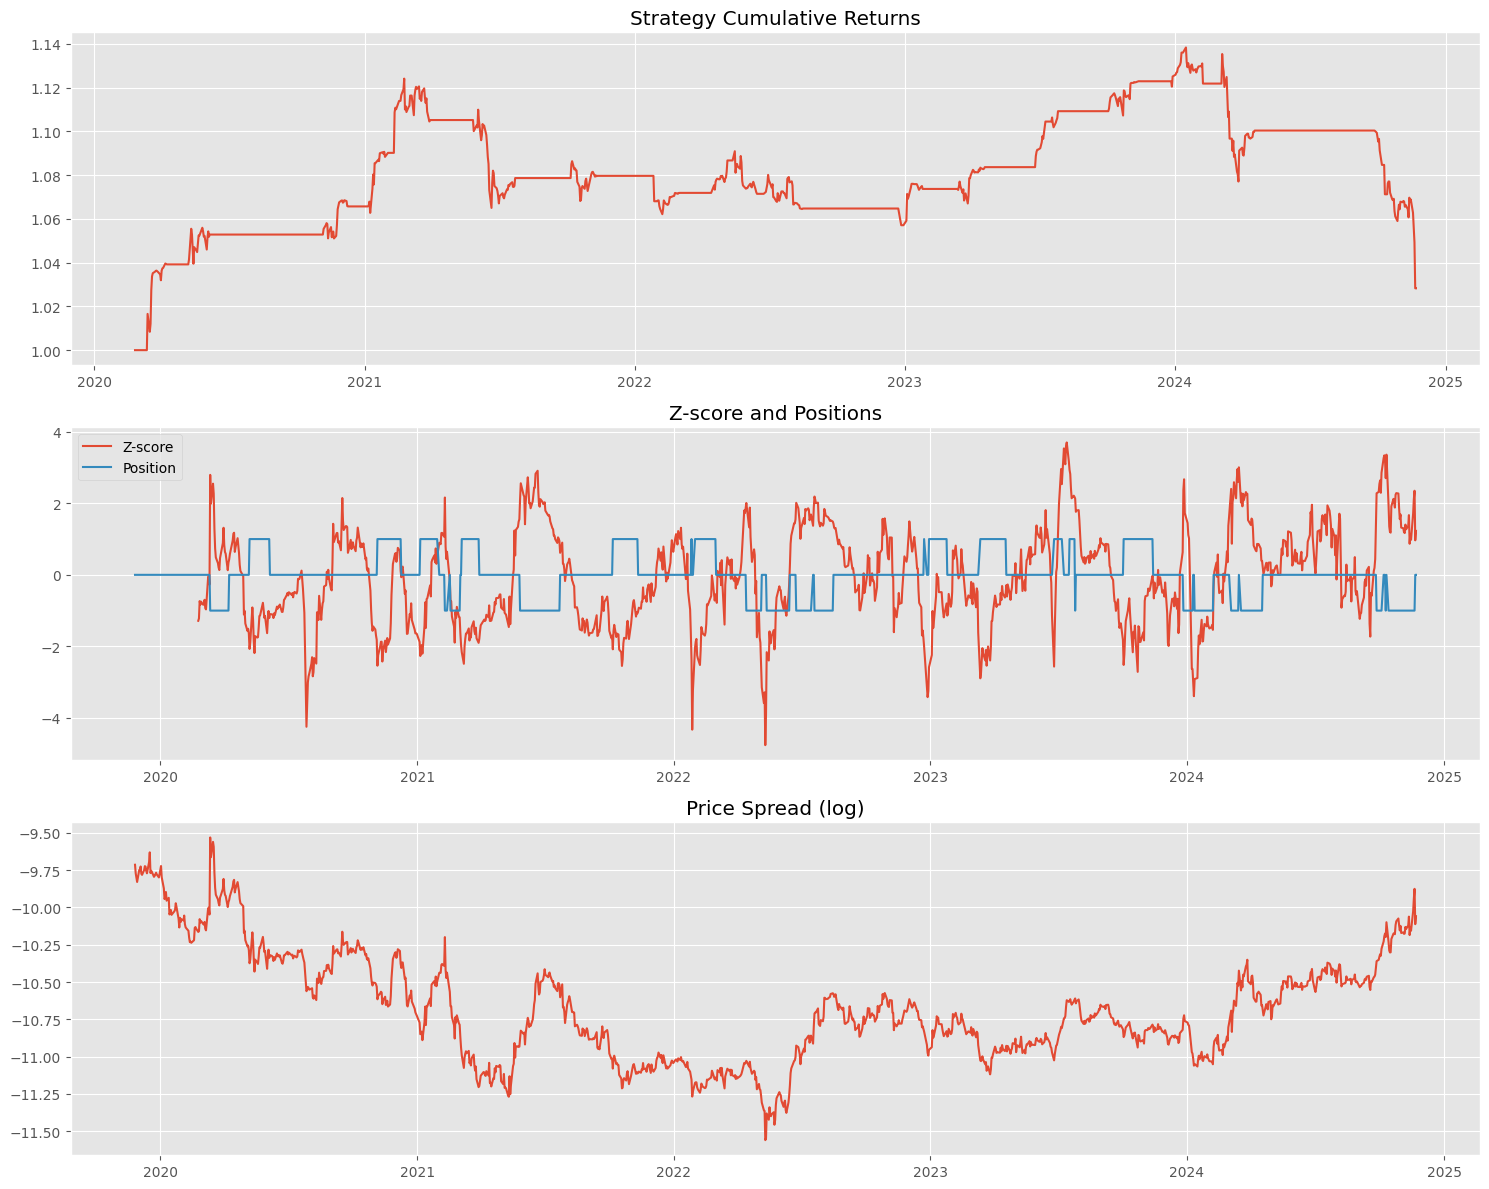

In [5]:
class PairsTrader:
    def __init__(self, lookback_period=60, holding_window=20, z_score_threshold=2, 
                 correlation_threshold=0.4, max_position=0.2, stop_loss=0.02, vol_ratio=1.4):
        self.lookback_period = lookback_period  # Longer period for signal generation
        self.holding_window = holding_window    # Minimum holding period
        self.z_score_threshold = z_score_threshold
        self.correlation_threshold = correlation_threshold
        self.max_position = max_position
        self.stop_loss = stop_loss
        self.vol_ratio = vol_ratio
    
    def calculate_signals(self, prices_df):
        # Calculate log price ratio
        log_prices = np.log(prices_df)
        spread = log_prices['MSTR'] - (self.vol_ratio * log_prices['BTC'])
        
        # Calculate longer-term moving averages and std
        ma = spread.rolling(window=self.lookback_period).mean()
        std = spread.rolling(window=self.lookback_period).std()
        z_score = (spread - ma) / std
        
        # Calculate rolling correlation on returns
        returns_df = prices_df.pct_change()
        rolling_corr = returns_df.rolling(window=self.lookback_period).corr().unstack()['MSTR']['BTC']
        
        signals = pd.DataFrame(index=prices_df.index)
        signals['z_score'] = z_score
        signals['correlation'] = rolling_corr
        signals['spread'] = spread
        signals['position'] = 0
        
        # Generate initial positions
        signals.loc[z_score < -self.z_score_threshold, 'position'] = 1
        signals.loc[z_score > self.z_score_threshold, 'position'] = -1
        
        # Apply correlation filter
        signals.loc[rolling_corr < self.correlation_threshold, 'position'] = 0
        
        # Implement holding period logic
        position_changes = signals['position'].diff().abs()
        entry_dates = position_changes[position_changes > 0].index
        
        for entry_date in entry_dates:
            if entry_date + pd.Timedelta(days=self.holding_window) <= signals.index[-1]:
                holding_period = signals.loc[entry_date:entry_date + pd.Timedelta(days=self.holding_window)].index
                current_position = signals.loc[entry_date, 'position']
                signals.loc[holding_period, 'position'] = current_position
        
        # Exit conditions
        # 1. When spread reverts to mean (z-score crosses 0)
        exit_signal = (z_score * z_score.shift(1) < 0)  # z-score crosses 0
        signals.loc[exit_signal & (signals['position'].shift(self.holding_window) != 0), 'position'] = 0
        
        # 2. When spread moves too far against position
        stop_loss_signal = abs(z_score) > self.z_score_threshold * 1.5
        signals.loc[stop_loss_signal, 'position'] = 0
        
        return signals
    
    def backtest(self, prices_df):
        signals = self.calculate_signals(prices_df)
        returns_df = prices_df.pct_change()
        
        # Calculate position sizes with volatility adjustment
        position_sizes = signals['z_score'].abs() / signals['z_score'].abs().max()
        position_sizes = position_sizes * self.max_position
        position_sizes = position_sizes * signals['position']
        
        # Adjust BTC positions for volatility
        mstr_position = position_sizes
        btc_position = position_sizes * self.vol_ratio
        
        # Calculate strategy returns
        strategy_returns = pd.DataFrame(index=prices_df.index)
        strategy_returns['MSTR_return'] = mstr_position.shift(1) * returns_df['MSTR']
        strategy_returns['BTC_return'] = -btc_position.shift(1) * returns_df['BTC']
        strategy_returns['total_return'] = strategy_returns['MSTR_return'] + strategy_returns['BTC_return']
        
        # Apply stop loss
        stop_loss_mask = (strategy_returns['total_return'].abs() > self.stop_loss)
        strategy_returns.loc[stop_loss_mask, 'total_return'] = -self.stop_loss
        
        strategy_returns['cumulative_return'] = (1 + strategy_returns['total_return']).cumprod()
        
        return strategy_returns, signals

# Usage
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

mstr = yf.download('MSTR', start=start_date, end=end_date)
btc = yf.download('BTC-USD', start=start_date, end=end_date)
btc = btc.reindex(mstr.index)

prices_df = pd.DataFrame({
    'MSTR': mstr['Adj Close'],
    'BTC': btc['Adj Close']
})

# Initialize and run backtest
trader = PairsTrader(
    lookback_period=60,    # 60-day lookback for signal generation
    holding_window=20,     # 20-day minimum holding period
    z_score_threshold=2,   # Entry threshold
    vol_ratio=1.4
)
strategy_returns, signals = trader.backtest(prices_df)

# Analysis of holding periods
position_changes = signals['position'].diff().abs()
trade_entries = position_changes[position_changes > 0]
print(f"Number of trades: {len(trade_entries)}")
print(f"Average holding period: {signals['position'].groupby((signals['position'] != signals['position'].shift()).cumsum()).count().mean():.1f} days")

# Plot results
plt.figure(figsize=(15, 12))

# Plot 1: Cumulative Returns
plt.subplot(3, 1, 1)
plt.plot(strategy_returns['cumulative_return'])
plt.title('Strategy Cumulative Returns')
plt.grid(True)

# Plot 2: Z-score and Positions
plt.subplot(3, 1, 2)
plt.plot(signals['z_score'], label='Z-score')
plt.plot(signals['position'], label='Position')
plt.title('Z-score and Positions')
plt.legend()
plt.grid(True)

# Plot 3: Spread
plt.subplot(3, 1, 3)
plt.plot(signals['spread'])
plt.title('Price Spread (log)')
plt.grid(True)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Options Trading Statistics:
Average position size (active signals only): 0.679
Average option payoff (expiration days only): 0.54%


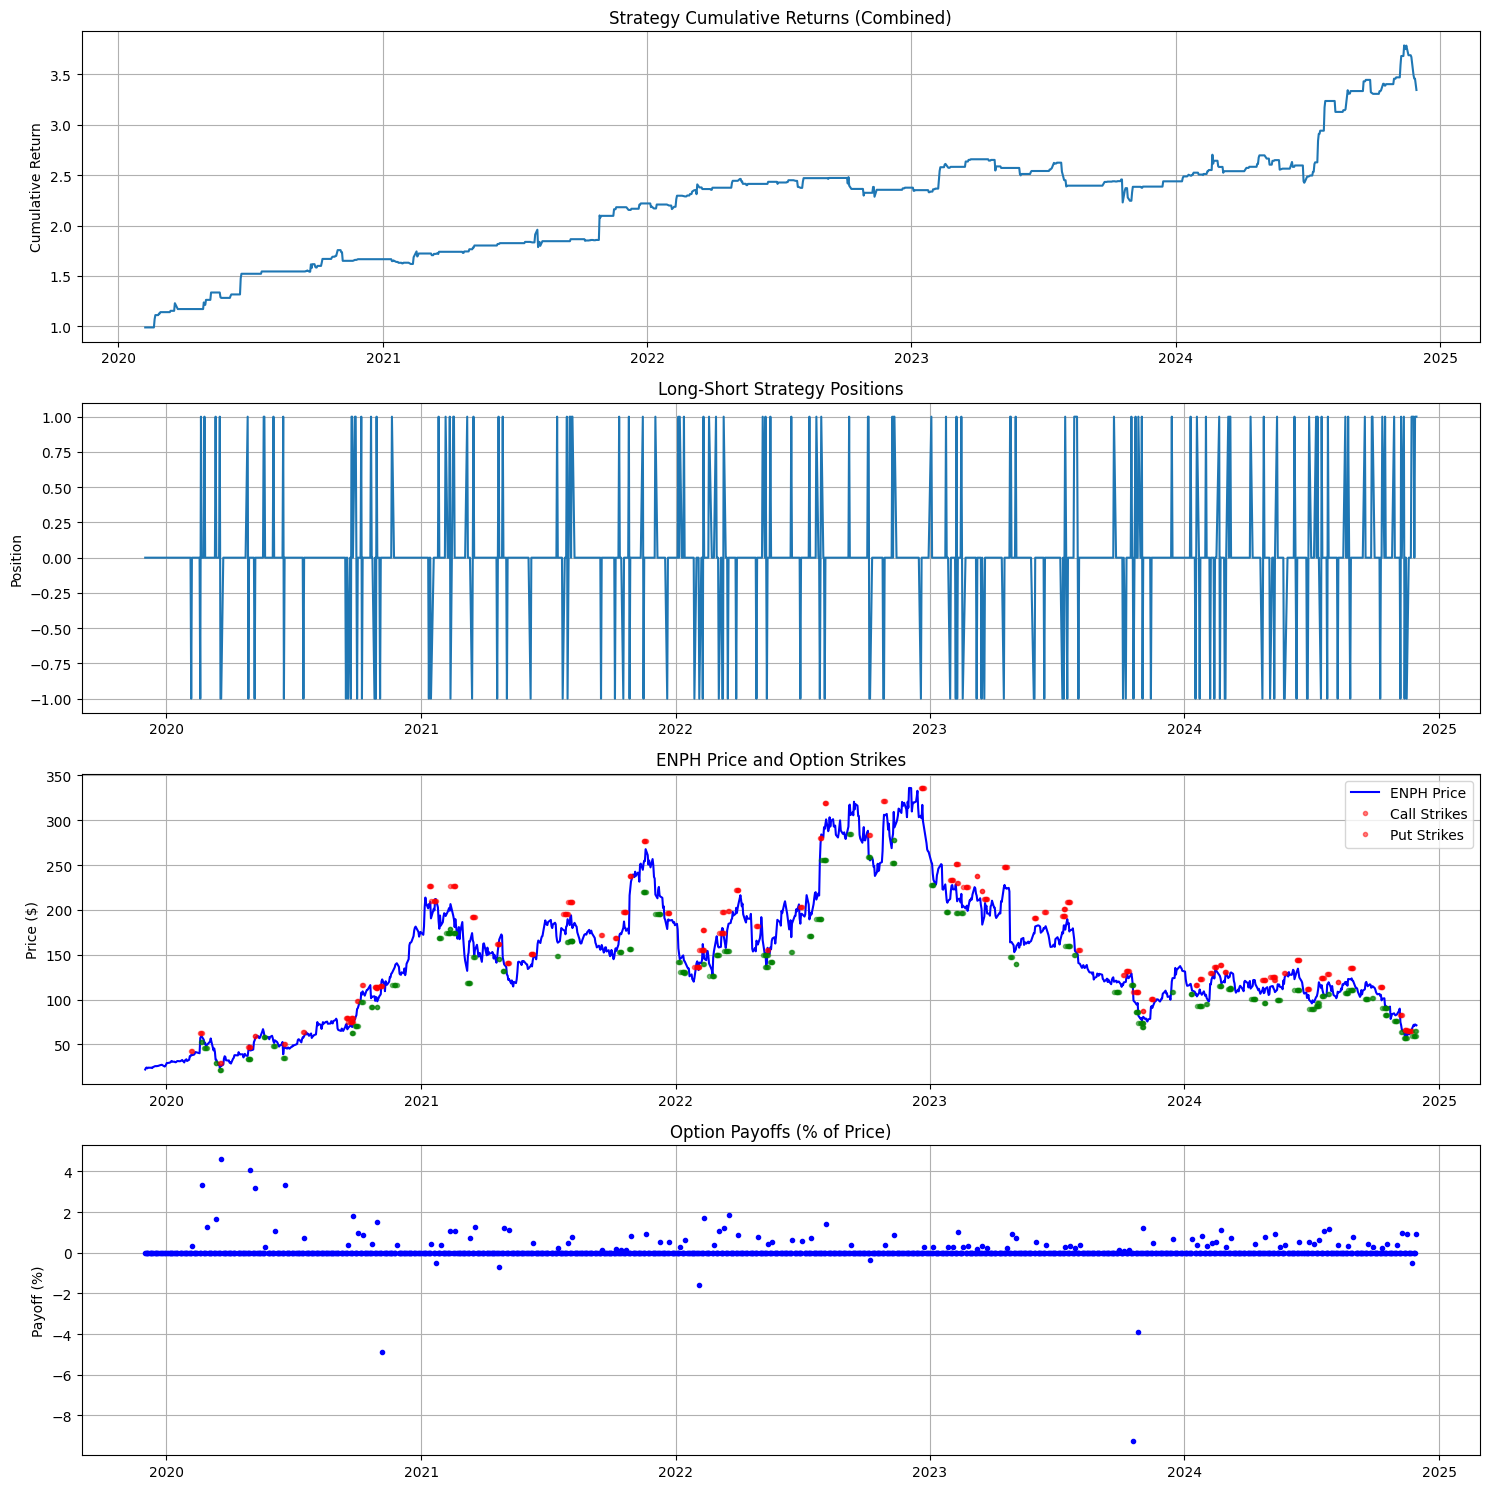

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

class PairsTrader:
    def __init__(self, ticker1='MSTR', ticker2='BTC-USD', z_score_window=45, z_score_threshold=1.25, correlation_threshold=0.5,
                 max_position=1, stop_loss=0.2, vol_ratio=1.4, vol_premium_multiplier=0.015):
        self.ticker1 = ticker1
        self.ticker2 = ticker2
        self.z_score_window = z_score_window
        self.z_score_threshold = z_score_threshold
        self.correlation_threshold = correlation_threshold
        self.max_position = max_position
        self.stop_loss = stop_loss
        self.vol_ratio = vol_ratio
        self.vol_premium_multiplier = vol_premium_multiplier  # 2% multiplier for volatility-based premium
    
    def calculate_signals(self, returns_df):
        # Original signal calculation remains the same
        vol_adjusted_diff = returns_df[self.ticker1] - (self.vol_ratio * returns_df[self.ticker2])
        
        # Calculate z-score using volatility-adjusted differences
        rolling_mean = vol_adjusted_diff.rolling(window=self.z_score_window).mean()
        rolling_std = vol_adjusted_diff.rolling(window=self.z_score_window).std()
        z_score = (vol_adjusted_diff - rolling_mean) / rolling_std
        
        # Calculate rolling correlation
        rolling_corr = returns_df.rolling(window=self.z_score_window).corr().unstack()[self.ticker1][self.ticker2]
        
        # Calculate annualized volatility for option premium
        rolling_vol = returns_df[self.ticker1].rolling(window=self.z_score_window).std() * np.sqrt(252)
        
        signals = pd.DataFrame(index=returns_df.index)
        signals['z_score'] = z_score
        signals['correlation'] = rolling_corr
        signals['position'] = 0
        signals['annualized_vol'] = rolling_vol
        
        # Generate positions based on volatility-adjusted z-score
        signals.loc[z_score < -self.z_score_threshold, 'position'] = 1
        signals.loc[z_score > self.z_score_threshold, 'position'] = -1
        signals.loc[rolling_corr < self.correlation_threshold, 'position'] = 0
        signals.loc[abs(z_score) < 0.5, 'position'] = 0
        
        # Modified position sizing: using a sigmoid-like function for smoother scaling
        z_score_for_sizing = z_score.copy()
        z_score_for_sizing = z_score_for_sizing.clip(-3, 3)  # Limit extreme values
        position_sizes = 1 / (1 + np.exp(-1.5 * (abs(z_score_for_sizing) - self.z_score_threshold)))
        signals['position_size'] = position_sizes * self.max_position
        
        return signals
    
    def calculate_weekly_options_payoff(self, prices_df, signals):
        # Create a copy of the dataframe with timezone-naive index
        prices_df = prices_df.copy()
        prices_df.index = pd.to_datetime(prices_df.index).tz_localize(None)
        
        # Create a DataFrame for option positions and payoffs
        options_df = pd.DataFrame(index=prices_df.index)
        options_df[f'{self.ticker1}_price'] = prices_df[self.ticker1]
        options_df['signal'] = signals['position']
        
        # Calculate position sizes using sigmoid function
        z_score_for_sizing = signals['z_score'].copy()
        z_score_for_sizing = z_score_for_sizing.clip(-3, 3)  # Limit extreme values
        position_sizes = 1 / (1 + np.exp(-1.5 * (abs(z_score_for_sizing) - self.z_score_threshold)))
        options_df['position_size'] = position_sizes * self.max_position
        
        options_df['week'] = options_df.index.to_period('W-FRI')
        
        # Get week end prices for all weeks (including next week)
        week_end_prices = {}
        for week in options_df['week'].unique():
            week_data = options_df[options_df['week'] == week]
            week_end_prices[week] = week_data[f'{self.ticker1}_price'].iloc[-1]
        
        # Detect signal changes
        signal_changes = options_df['signal'] != options_df['signal'].shift(1)
        change_points = options_df[signal_changes].index
        
        # Initialize columns for multiple positions
        options_df['active_positions'] = options_df.apply(lambda x: [], axis=1)
        options_df['option_payoff'] = 0.0
        
        # Process each signal change
        for idx in change_points:
            current_signal = options_df.loc[idx, 'signal']
            if current_signal == 0:
                continue
                
            current_price = options_df.loc[idx, f'{self.ticker1}_price']
            current_week = options_df.loc[idx, 'week']
            position_size = options_df.loc[idx, 'position_size']
            
            # Calculate dynamic premium based on volatility
            entry_vol = signals.loc[idx, 'annualized_vol']
            premium = (entry_vol ** 2) * self.vol_premium_multiplier
            
            # Find expiration week (next week if signal change is on last day of week)
            is_last_day_of_week = idx == options_df[options_df['week'] == current_week].index[-1]
            expiration_week = current_week + 1 if is_last_day_of_week else current_week
            
            # Only create position if we have an expiration price
            if expiration_week in week_end_prices:
                # Create new position dictionary
                new_position = {
                    'signal': current_signal,
                    'entry_price': current_price,
                    'strike_price': current_price * (1.1 if current_signal == -1 else 0.9),
                    'expiration_week': expiration_week,
                    'position_size': position_size,
                    'premium': premium,  # Store the dynamic premium
                    'entry_date': idx,
                    'vol': entry_vol
                }
                
                # Add position to all days until expiration
                mask = (options_df.index >= idx) & (options_df['week'] <= expiration_week)
                for day in options_df[mask].index:
                    options_df.at[day, 'active_positions'].append(new_position.copy())
        
        # Calculate payoffs at expiration
        for week in options_df['week'].unique():
            week_end_idx = options_df[options_df['week'] == week].index[-1]
            week_end_price = options_df.loc[week_end_idx, f'{self.ticker1}_price']
            
            # Process all positions expiring this week
            for position in options_df.loc[week_end_idx, 'active_positions']:
                if position['expiration_week'] == week:
                    # Calculate base payoff
                    if position['signal'] == -1:  # Short call
                        payoff = min(0, position['strike_price'] - week_end_price)
                    else:  # Short put
                        payoff = min(0, week_end_price - position['strike_price'])
                    
                    # Add premium and adjust for position size
                    adjusted_payoff = (payoff + position['entry_price'] * position['premium']) * position['position_size']
                    options_df.loc[week_end_idx, 'option_payoff'] += adjusted_payoff
        
        # Add additional analytics columns
        options_df['active_option_count'] = options_df['active_positions'].apply(len)
        options_df['avg_position_vol'] = options_df['active_positions'].apply(
            lambda x: np.mean([p['vol'] for p in x]) if x else 0)
        options_df['avg_premium'] = options_df['active_positions'].apply(
            lambda x: np.mean([p['premium'] for p in x]) if x else 0)
        
        return options_df

    def backtest(self, returns_df, prices_df):
        signals = self.calculate_signals(returns_df)
        
        # Use previously calculated position sizes
        ticker1_position = signals['position_size'] * signals['position']
        ticker2_position = ticker1_position * self.vol_ratio
        
        strategy_returns = pd.DataFrame(index=returns_df.index)
        strategy_returns[f'{self.ticker1}_return'] = ticker1_position.shift(1) * returns_df[self.ticker1]
        strategy_returns[f'{self.ticker2}_return'] = -ticker2_position.shift(1) * returns_df[self.ticker2]
        
        # Calculate options payoffs with position size adjustment
        options_df = self.calculate_weekly_options_payoff(prices_df, signals)
        
        # Add options returns (already adjusted for position size)
        strategy_returns['options_return'] = options_df['option_payoff'] / prices_df[self.ticker1]
        
        # Calculate total strategy return
        strategy_returns['total_return'] = (
            strategy_returns[f'{self.ticker1}_return'] + 
            strategy_returns[f'{self.ticker2}_return'] + 
            strategy_returns['options_return']
        )
        
        strategy_returns['cumulative_return'] = (1 + strategy_returns['total_return']).cumprod()
        
        return strategy_returns, signals, options_df

# Download and align data for ticker1 and ticker2
ticker1 = 'ENPH'
ticker2 = 'SEDG'

# Calculate the date range (5 years from today)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Download data for both tickers
ticker1_data = yf.download(ticker1, start=start_date, end=end_date)
ticker2_data = yf.download(ticker2, start=start_date, end=end_date)

# Align ticker2 prices with ticker1 trading days
ticker2_data = ticker2_data.reindex(ticker1_data.index)

# Calculate daily returns and volatility
ticker1_returns = ticker1_data['Adj Close'].pct_change()
ticker2_returns = ticker2_data['Adj Close'].pct_change()

ticker1_vol = ticker1_returns.std() * np.sqrt(252)
ticker2_vol = ticker2_returns.std() * np.sqrt(252)
vol_ratio = ticker1_vol / ticker2_vol

# Create DataFrames for returns and prices
returns_df = pd.DataFrame({
    ticker1: ticker1_returns,
    ticker2: ticker2_returns
})

prices_df = pd.DataFrame({
    ticker1: ticker1_data['Adj Close'],
    ticker2: ticker2_data['Adj Close']
})

# Initialize and run backtest with calculated vol_ratio
trader = PairsTrader(ticker1=ticker1, ticker2=ticker2, vol_ratio=vol_ratio)
strategy_returns, signals, options_df = trader.backtest(returns_df, prices_df)

# Calculate percentage option payoffs
options_df['option_payoff_pct'] = options_df['option_payoff'] / prices_df[ticker1]

# Print detailed statistics
print("\nOptions Trading Statistics:")
# Average position size (excluding zeros)
non_zero_positions = options_df['position_size'][options_df['signal'] != 0]
print(f"Average position size (active signals only): {non_zero_positions.mean():.3f}")

# Average option payoff (excluding zeros)
non_zero_payoffs = options_df['option_payoff_pct'][options_df['option_payoff'] != 0]
print(f"Average option payoff (expiration days only): {non_zero_payoffs.mean():.2%}")

# Enhanced visualization
plt.figure(figsize=(15, 15))

# Plot 1: Strategy Cumulative Returns
plt.subplot(4, 1, 1)
plt.plot(strategy_returns['cumulative_return'])
plt.title('Strategy Cumulative Returns (Combined)')
plt.grid(True)
plt.ylabel('Cumulative Return')

# Plot 2: Long-Short Strategy Positions
plt.subplot(4, 1, 2)
plt.plot(signals['position'])
plt.title('Long-Short Strategy Positions')
plt.grid(True)
plt.ylabel('Position')

# Plot 3: Price and Option Strikes
plt.subplot(4, 1, 3)
plt.plot(prices_df.index, prices_df[ticker1], 'b-', label=f'{ticker1} Price')
for idx in options_df.index:
    for position in options_df.loc[idx, 'active_positions']:
        if position['signal'] == -1:
            plt.plot(idx, position['strike_price'], 'r.', alpha=0.5)
        else:
            plt.plot(idx, position['strike_price'], 'g.', alpha=0.5)
plt.legend([f'{ticker1} Price', 'Call Strikes', 'Put Strikes'])
plt.title(f'{ticker1} Price and Option Strikes')
plt.grid(True)
plt.ylabel('Price ($)')

# Plot 4: Option Payoffs (Percentage)
plt.subplot(4, 1, 4)
plt.plot(options_df.index, options_df['option_payoff_pct'] * 100, 'b.')
plt.title('Option Payoffs (% of Price)')
plt.grid(True)
plt.ylabel('Payoff (%)')

plt.tight_layout()
plt.show()

# Save detailed results to CSV
results_df = pd.DataFrame({
    'Date': options_df.index,
    f'{ticker1}_Price': prices_df[ticker1],
    'Long_Short_Position': signals['position'],
    'Position_Size': options_df['position_size'],
    'Option_Payoff_Dollar': options_df['option_payoff'],
    'Option_Payoff_Pct': options_df['option_payoff_pct'],
    'Long_Short_Return': strategy_returns[f'{trader.ticker1}_return'] + strategy_returns[f'{trader.ticker2}_return'],
    'Options_Return': strategy_returns['options_return'],
    'Total_Return': strategy_returns['total_return'],
    'Cumulative_Return': strategy_returns['cumulative_return'],
    'Active_Option_Count': options_df['active_positions'].apply(len)
})

# Add columns for active options details
max_positions = max(len(pos) for pos in options_df['active_positions'])
for i in range(max_positions):
    results_df[f'Option_{i+1}_Signal'] = options_df['active_positions'].apply(
        lambda x: x[i]['signal'] if i < len(x) else None)
    results_df[f'Option_{i+1}_Strike'] = options_df['active_positions'].apply(
        lambda x: x[i]['strike_price'] if i < len(x) else None)
    results_df[f'Option_{i+1}_Size'] = options_df['active_positions'].apply(
        lambda x: x[i]['position_size'] if i < len(x) else None)

# Save to CSV
results_df.to_csv('enhanced_strategy_results.csv', index=False)

In [8]:
def analyze_pairs(tickers, start_date, end_date):
    # Download data
    data = pd.DataFrame()
    for ticker in tickers:
        stock = yf.download(ticker, start=start_date, end=end_date)
        data[ticker] = stock['Adj Close']
    
    # Calculate returns
    returns = data.pct_change()
    
    # Calculate correlations
    corr_matrix = returns.corr()
    
    # Calculate volatilities
    vols = returns.std() * np.sqrt(252)
    
    # Calculate vol ratios for each pair
    pairs_analysis = []
    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            ticker1, ticker2 = tickers[i], tickers[j]
            correlation = corr_matrix.loc[ticker1, ticker2]
            vol_ratio = vols[ticker1] / vols[ticker2]
            
            pairs_analysis.append({
                'Pair': f"{ticker1} vs {ticker2}",
                'Correlation': correlation,
                'Vol_Ratio': vol_ratio,
                'Ticker1_Vol': vols[ticker1],
                'Ticker2_Vol': vols[ticker2]
            })
    
    return pd.DataFrame(pairs_analysis).sort_values('Correlation', ascending=False)

# Example usage
crypto_tickers = ['MSTR', 'COIN', 'RIOT', 'HUT', 'CLSK', 'BTC-USD']
tech_tickers = ['NVDA', 'AMD', 'MSFT', 'GOOGL', 'META']
finance_tickers = ['GS', 'MS', 'JPM', 'BAC']

# Analyze each group
end_date = datetime.now()
start_date = end_date - timedelta(days=2*365)  # 2 years of data

print("Crypto-Related Pairs:")
crypto_analysis = analyze_pairs(crypto_tickers, start_date, end_date)
print(crypto_analysis)

print("\nTech Pairs:")
tech_analysis = analyze_pairs(tech_tickers, start_date, end_date)
print(tech_analysis)

print("\nFinancial Pairs:")
finance_analysis = analyze_pairs(finance_tickers, start_date, end_date)
print(finance_analysis)

[*********************100%***********************]  1 of 1 completed

Crypto-Related Pairs:



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


               Pair  Correlation  Vol_Ratio  Ticker1_Vol  Ticker2_Vol
10     RIOT vs CLSK     0.801842   0.867449     0.965727     1.113295
9       RIOT vs HUT     0.766217   0.894545     0.965727     1.079574
5      COIN vs RIOT     0.724732   0.916837     0.885414     0.965727
4   MSTR vs BTC-USD     0.703850   1.777761     0.917234     0.515949
12      HUT vs CLSK     0.703343   0.969711     1.079574     1.113295
1      MSTR vs RIOT     0.685895   0.949786     0.917234     0.965727
0      MSTR vs COIN     0.678654   1.035939     0.917234     0.885414
6       COIN vs HUT     0.672607   0.820151     0.885414     1.079574
7      COIN vs CLSK     0.662726   0.795309     0.885414     1.113295
3      MSTR vs CLSK     0.635203   0.823892     0.917234     1.113295
2       MSTR vs HUT     0.630686   0.849626     0.917234     1.079574
11  RIOT vs BTC-USD     0.615844   1.871749     0.965727     0.515949
13   HUT vs BTC-USD     0.577512   2.092404     1.079574     0.515949
14  CLSK vs BTC-USD 

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

            Pair  Correlation  Vol_Ratio  Ticker1_Vol  Ticker2_Vol
0    NVDA vs AMD     0.634096   1.077549     0.515475     0.478377
7  MSFT vs GOOGL     0.564958   0.799185     0.233598     0.292296
8   MSFT vs META     0.564810   0.594936     0.233598     0.392645
9  GOOGL vs META     0.531266   0.744427     0.292296     0.392645
1   NVDA vs MSFT     0.527637   2.206670     0.515475     0.233598
4    AMD vs MSFT     0.491933   2.047861     0.478377     0.233598
6    AMD vs META     0.416276   1.218345     0.478377     0.392645
5   AMD vs GOOGL     0.415379   1.636620     0.478377     0.292296
3   NVDA vs META     0.413029   1.312826     0.515475     0.392645
2  NVDA vs GOOGL     0.393796   1.763538     0.515475     0.292296

Financial Pairs:



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

         Pair  Correlation  Vol_Ratio  Ticker1_Vol  Ticker2_Vol
0    GS vs MS     0.734180   0.958506     0.249870     0.260687
5  JPM vs BAC     0.718066   0.877133     0.222103     0.253214
2   GS vs BAC     0.715232   0.986792     0.249870     0.253214
4   MS vs BAC     0.703241   1.029512     0.260687     0.253214
1   GS vs JPM     0.683220   1.125021     0.249870     0.222103
3   MS vs JPM     0.610837   1.173724     0.260687     0.222103


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Pair Volatilities:
MSTR_BTC-USD: 16.89%
AMAT_LRCX: 5.11%
NVDA_AMD: 6.26%
LCID_RIVN: 9.81%
ENPH_SEDG: 10.88%

Initial Inverse Volatility Weights:
MSTR_BTC-USD: 9.73%
AMAT_LRCX: 32.15%
NVDA_AMD: 26.26%
LCID_RIVN: 16.75%
ENPH_SEDG: 15.11%

Pair Start Dates:
MSTR_BTC-USD: 2020-02-07 00:00:00
AMAT_LRCX: 2020-02-07 00:00:00
NVDA_AMD: 2020-02-07 00:00:00
LCID_RIVN: 2022-01-18 00:00:00
ENPH_SEDG: 2020-02-07 00:00:00

Number of active pairs over time:
active_pairs
0      46
8     490
10    721
Name: count, dtype: int64

Average Number of Active Pairs: 8.85


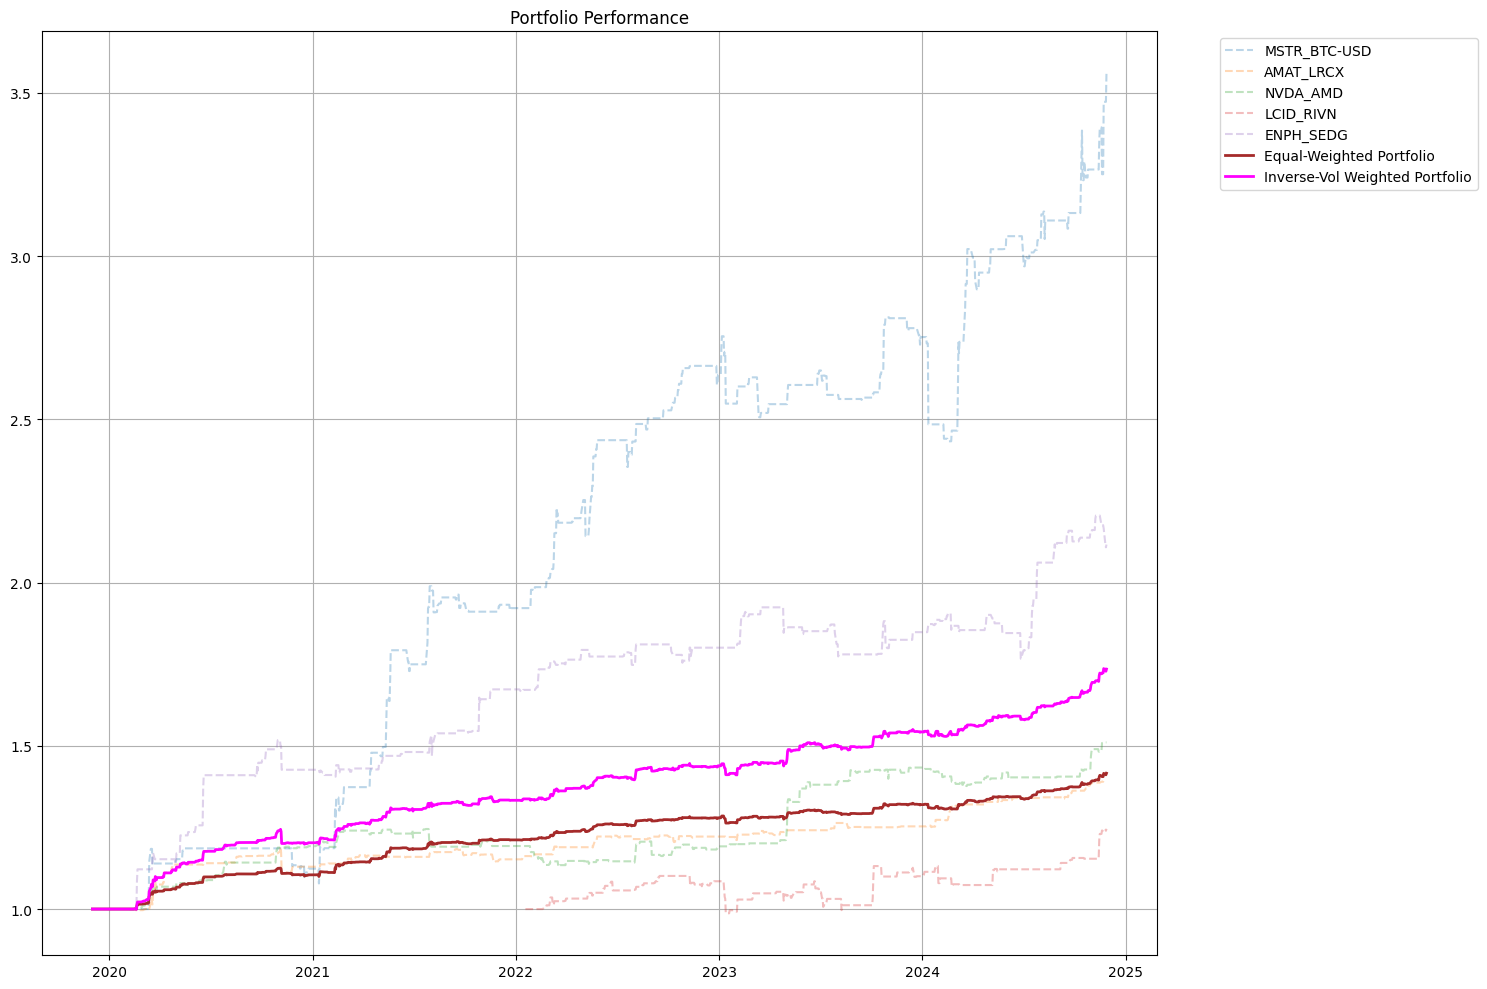


Equal-Weighted Portfolio Statistics:
Annual Return: 7.26%
Annual Volatility: 2.71%
Sharpe Ratio: 2.68
Max Drawdown: -2.27%

Inverse-Vol Weighted Portfolio Statistics:
Annual Return: 11.77%
Annual Volatility: 4.15%
Sharpe Ratio: 2.84
Max Drawdown: -3.67%


In [1]:
# Define pairs and their configurations
PAIRS = [
    {'ticker1': 'MSTR', 'ticker2': 'BTC-USD'},
    {'ticker1': 'AMAT', 'ticker2': 'LRCX'},
    {'ticker1': 'NVDA', 'ticker2': 'AMD'},
    {'ticker1': 'LCID', 'ticker2': 'RIVN'},
    {'ticker1': 'ENPH', 'ticker2': 'SEDG'}
]

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

class PairsTrader:
    def __init__(self, ticker1='MSTR', ticker2='BTC-USD', z_score_window=45, z_score_threshold=1.5, correlation_threshold=0.5,
                 max_position=1, stop_loss=0.2, vol_ratio=1.4, vol_premium_multiplier=0.015):
        self.ticker1 = ticker1
        self.ticker2 = ticker2
        self.z_score_window = z_score_window
        self.z_score_threshold = z_score_threshold
        self.correlation_threshold = correlation_threshold
        self.max_position = max_position
        self.stop_loss = stop_loss
        self.vol_ratio = vol_ratio
        self.vol_premium_multiplier = vol_premium_multiplier  # 2% multiplier for volatility-based premium
    
    def calculate_signals(self, returns_df):
        # Original signal calculation remains the same
        vol_adjusted_diff = returns_df[self.ticker1] - (self.vol_ratio * returns_df[self.ticker2])
        
        # Calculate z-score using volatility-adjusted differences
        rolling_mean = vol_adjusted_diff.rolling(window=self.z_score_window).mean()
        rolling_std = vol_adjusted_diff.rolling(window=self.z_score_window).std()
        z_score = (vol_adjusted_diff - rolling_mean) / rolling_std
        
        # Calculate rolling correlation
        rolling_corr = returns_df.rolling(window=self.z_score_window).corr().unstack()[self.ticker1][self.ticker2]
        
        # Calculate annualized volatility for option premium
        rolling_vol = returns_df[self.ticker1].rolling(window=self.z_score_window).std() * np.sqrt(252)
        
        signals = pd.DataFrame(index=returns_df.index)
        signals['z_score'] = z_score
        signals['correlation'] = rolling_corr
        signals['position'] = 0
        signals['annualized_vol'] = rolling_vol
        
        # Generate positions based on volatility-adjusted z-score
        signals.loc[z_score < -self.z_score_threshold, 'position'] = 1
        signals.loc[z_score > self.z_score_threshold, 'position'] = -1
        signals.loc[rolling_corr < self.correlation_threshold, 'position'] = 0
        signals.loc[abs(z_score) < 0.5, 'position'] = 0
        
        # Modified position sizing: using a sigmoid-like function for smoother scaling
        z_score_for_sizing = z_score.copy()
        z_score_for_sizing = z_score_for_sizing.clip(-3, 3)  # Limit extreme values
        position_sizes = 1 / (1 + np.exp(-1.5 * (abs(z_score_for_sizing) - self.z_score_threshold)))
        signals['position_size'] = position_sizes * self.max_position
        
        return signals
    
    def calculate_weekly_options_payoff(self, prices_df, signals):
        # Create a copy of the dataframe with timezone-naive index
        prices_df = prices_df.copy()
        prices_df.index = pd.to_datetime(prices_df.index).tz_localize(None)
        
        # Create a DataFrame for option positions and payoffs
        options_df = pd.DataFrame(index=prices_df.index)
        options_df[f'{self.ticker1}_price'] = prices_df[self.ticker1]
        options_df['signal'] = signals['position']
        
        # Calculate position sizes using sigmoid function
        z_score_for_sizing = signals['z_score'].copy()
        z_score_for_sizing = z_score_for_sizing.clip(-3, 3)  # Limit extreme values
        position_sizes = 1 / (1 + np.exp(-1.5 * (abs(z_score_for_sizing) - self.z_score_threshold)))
        options_df['position_size'] = position_sizes * self.max_position
        
        options_df['week'] = options_df.index.to_period('W-FRI')
        
        # Get week end prices for all weeks (including next week)
        week_end_prices = {}
        for week in options_df['week'].unique():
            week_data = options_df[options_df['week'] == week]
            week_end_prices[week] = week_data[f'{self.ticker1}_price'].iloc[-1]
        
        # Detect signal changes
        signal_changes = options_df['signal'] != options_df['signal'].shift(1)
        change_points = options_df[signal_changes].index
        
        # Initialize columns for multiple positions
        options_df['active_positions'] = options_df.apply(lambda x: [], axis=1)
        options_df['option_payoff'] = 0.0
        
        # Process each signal change
        for idx in change_points:
            current_signal = options_df.loc[idx, 'signal']
            if current_signal == 0:
                continue
                
            current_price = options_df.loc[idx, f'{self.ticker1}_price']
            current_week = options_df.loc[idx, 'week']
            position_size = options_df.loc[idx, 'position_size']
            
            # Calculate dynamic premium based on volatility
            entry_vol = signals.loc[idx, 'annualized_vol']
            premium = (entry_vol ** 2) * self.vol_premium_multiplier
            
            # Find expiration week (next week if signal change is on last day of week)
            is_last_day_of_week = idx == options_df[options_df['week'] == current_week].index[-1]
            expiration_week = current_week + 1 if is_last_day_of_week else current_week
            
            # Only create position if we have an expiration price
            if expiration_week in week_end_prices:
                # Create new position dictionary
                new_position = {
                    'signal': current_signal,
                    'entry_price': current_price,
                    'strike_price': current_price * (1.1 if current_signal == -1 else 0.9),
                    'expiration_week': expiration_week,
                    'position_size': position_size,
                    'premium': premium,  # Store the dynamic premium
                    'entry_date': idx,
                    'vol': entry_vol
                }
                
                # Add position to all days until expiration
                mask = (options_df.index >= idx) & (options_df['week'] <= expiration_week)
                for day in options_df[mask].index:
                    options_df.at[day, 'active_positions'].append(new_position.copy())
        
        # Calculate payoffs at expiration
        for week in options_df['week'].unique():
            week_end_idx = options_df[options_df['week'] == week].index[-1]
            week_end_price = options_df.loc[week_end_idx, f'{self.ticker1}_price']
            
            # Process all positions expiring this week
            for position in options_df.loc[week_end_idx, 'active_positions']:
                if position['expiration_week'] == week:
                    # Calculate base payoff
                    if position['signal'] == -1:  # Short call
                        payoff = min(0, position['strike_price'] - week_end_price)
                    else:  # Short put
                        payoff = min(0, week_end_price - position['strike_price'])
                    
                    # Add premium and adjust for position size
                    adjusted_payoff = (payoff + position['entry_price'] * position['premium']) * position['position_size']
                    options_df.loc[week_end_idx, 'option_payoff'] += adjusted_payoff
        
        # Add additional analytics columns
        options_df['active_option_count'] = options_df['active_positions'].apply(len)
        options_df['avg_position_vol'] = options_df['active_positions'].apply(
            lambda x: np.mean([p['vol'] for p in x]) if x else 0)
        options_df['avg_premium'] = options_df['active_positions'].apply(
            lambda x: np.mean([p['premium'] for p in x]) if x else 0)
        
        return options_df

    def backtest(self, returns_df, prices_df):
        signals = self.calculate_signals(returns_df)
        
        # Calculate position sizes for pair trading
        position_sizes = signals['z_score'].abs() / signals['z_score'].abs().max()
        position_sizes = position_sizes * self.max_position
        position_sizes = position_sizes * signals['position']
        
        # Calculate pair trading returns
        ticker1_position = position_sizes
        ticker2_position = position_sizes * self.vol_ratio
        
        strategy_returns = pd.DataFrame(index=returns_df.index)
        strategy_returns[f'{self.ticker1}_return'] = ticker1_position.shift(1) * returns_df[self.ticker1]
        strategy_returns[f'{self.ticker2}_return'] = -ticker2_position.shift(1) * returns_df[self.ticker2]
        
        # Calculate options payoffs with position size adjustment
        options_df = self.calculate_weekly_options_payoff(prices_df, signals)
        
        # Add options returns (already adjusted for position size)
        strategy_returns['options_return'] = options_df['option_payoff'] / prices_df[self.ticker1]
        
        # Calculate total strategy return
        strategy_returns['total_return'] = (
            strategy_returns[f'{self.ticker1}_return'] + 
            strategy_returns[f'{self.ticker2}_return'] + 
            strategy_returns['options_return']
        )
        
        strategy_returns['cumulative_return'] = (1 + strategy_returns['total_return']).cumprod()
        
        return strategy_returns, signals, options_df


# Function to download and prepare data for a single pair
def prepare_pair_data(ticker1, ticker2, start_date, end_date):
    ticker1_data = yf.download(ticker1, start=start_date, end=end_date)
    ticker2_data = yf.download(ticker2, start=start_date, end=end_date)
    
    # Align data
    common_dates = ticker1_data.index.intersection(ticker2_data.index)
    ticker1_data = ticker1_data.loc[common_dates]
    ticker2_data = ticker2_data.loc[common_dates]
    
    # Calculate returns and volatility
    ticker1_returns = ticker1_data['Adj Close'].pct_change()
    ticker2_returns = ticker2_data['Adj Close'].pct_change()
    
    ticker1_vol = ticker1_returns.std() * np.sqrt(252)
    ticker2_vol = ticker2_returns.std() * np.sqrt(252)
    vol_ratio = ticker1_vol / ticker2_vol
    
    returns_df = pd.DataFrame({
        ticker1: ticker1_returns,
        ticker2: ticker2_returns
    })
    
    prices_df = pd.DataFrame({
        ticker1: ticker1_data['Adj Close'],
        ticker2: ticker2_data['Adj Close']
    })
    
    return returns_df, prices_df, vol_ratio

# Main execution code
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Store results for each pair
pair_results = {}
all_dates = set()

# Run backtest for each pair
for pair in PAIRS:
    ticker1, ticker2 = pair['ticker1'], pair['ticker2']
    returns_df, prices_df, vol_ratio = prepare_pair_data(ticker1, ticker2, start_date, end_date)
    
    # Store trading dates for this pair
    all_dates.update(returns_df.index)
    
    # Run backtest
    trader = PairsTrader(ticker1=ticker1, ticker2=ticker2, vol_ratio=vol_ratio)
    strategy_returns, signals, options_df = trader.backtest(returns_df, prices_df)
    
    # Store results
    pair_results[f"{ticker1}_{ticker2}"] = {
        'strategy_returns': strategy_returns,
        'signals': signals,
        'options_df': options_df,
        'volatility': strategy_returns['total_return'].std() * np.sqrt(252)
    }

# After collecting all pair results, modify the portfolio construction code:

# Create aligned portfolio DataFrame with all dates
portfolio_df = pd.DataFrame(index=sorted(all_dates))

# Add pair returns and handle missing data properly
for pair_name, result in pair_results.items():
    returns = result['strategy_returns']['total_return']
    portfolio_df[f'{pair_name}_return'] = returns
    # Calculate cumulative returns only where we have data
    portfolio_df[f'{pair_name}_cum_return'] = (1 + returns).cumprod()

# Calculate number of active pairs per day
portfolio_df['active_pairs'] = portfolio_df[[col for col in portfolio_df.columns if col.endswith('_return') and not col.startswith(('equal_', 'inv_vol_'))]].notna().sum(axis=1)

# Calculate equal-weighted portfolio return
equal_weighted_returns = pd.DataFrame(index=portfolio_df.index)
for pair_name in pair_results.keys():
    # Divide by number of active pairs each day instead of total number of pairs
    equal_weighted_returns[pair_name] = portfolio_df[f'{pair_name}_return'].divide(portfolio_df['active_pairs'])

portfolio_df['equal_weighted_return'] = equal_weighted_returns.sum(axis=1)
portfolio_df['equal_weighted_cum_return'] = (1 + portfolio_df['equal_weighted_return']).cumprod()

# Recalculate volatilities using aligned data
pair_vols = {}
for pair_name in pair_results.keys():
    # Calculate volatility only where we have data
    valid_returns = portfolio_df[f'{pair_name}_return'].dropna()
    if len(valid_returns) > 0:
        pair_vols[pair_name] = valid_returns.std() * np.sqrt(252)
    else:
        pair_vols[pair_name] = np.nan

# Print volatilities
print("\nPair Volatilities:")
for pair_name, vol in pair_vols.items():
    if not np.isnan(vol):
        print(f"{pair_name}: {vol:.2%}")

# Calculate and print initial inverse volatility weights
print("\nInitial Inverse Volatility Weights:")
active_pairs = {pair_name: vol for pair_name, vol in pair_vols.items() 
               if not np.isnan(vol)}
if active_pairs:
    total_inv_vol = sum(1/vol for vol in active_pairs.values() if vol > 0)
    initial_weights = {pair_name: (1/vol)/total_inv_vol if vol > 0 else 0 
                      for pair_name, vol in active_pairs.items()}
    for pair_name, weight in initial_weights.items():
        print(f"{pair_name}: {weight:.2%}")

# Calculate inverse volatility weights (dynamic)
def calculate_inv_vol_weights(row, pair_vols):
    active_pairs = {pair_name: vol for pair_name, vol in pair_vols.items() 
                   if not pd.isna(row[f'{pair_name}_return'])}
    if not active_pairs:
        return pd.Series(0, index=pair_vols.keys())
    total_inv_vol = sum(1/vol for vol in active_pairs.values() if vol > 0)
    weights = {pair_name: (1/vol)/total_inv_vol if vol > 0 else 0 
              for pair_name, vol in active_pairs.items()}
    # Add 0 weight for inactive pairs
    weights.update({pair_name: 0 for pair_name in pair_vols.keys() 
                   if pair_name not in active_pairs})
    return pd.Series(weights)

# Calculate dynamic inverse volatility weighted returns
inv_vol_weighted_returns = pd.DataFrame(index=portfolio_df.index)
for date in portfolio_df.index:
    weights = calculate_inv_vol_weights(portfolio_df.loc[date], pair_vols)
    for pair_name in pair_results.keys():
        pair_return = portfolio_df.loc[date, f'{pair_name}_return']
        inv_vol_weighted_returns.loc[date, pair_name] = pair_return * weights[pair_name] if not pd.isna(pair_return) else 0

portfolio_df['inv_vol_weighted_return'] = inv_vol_weighted_returns.sum(axis=1)
portfolio_df['inv_vol_weighted_cum_return'] = (1 + portfolio_df['inv_vol_weighted_return']).cumprod()

# Add diagnostic information
print("\nPair Start Dates:")
for pair_name in pair_results.keys():
    first_valid = portfolio_df[f'{pair_name}_return'].first_valid_index()
    print(f"{pair_name}: {first_valid}")

print("\nNumber of active pairs over time:")
print(portfolio_df['active_pairs'].value_counts().sort_index())

# Print average number of active pairs
print(f"\nAverage Number of Active Pairs: {portfolio_df['active_pairs'].mean():.2f}")

# Modified visualization code
plt.figure(figsize=(15, 10))

# Plot individual pair cumulative returns
for pair_name in pair_results.keys():
    cum_returns = portfolio_df[f'{pair_name}_cum_return']
    valid_data = cum_returns.dropna()
    if not valid_data.empty:
        plt.plot(valid_data.index, valid_data, 
                alpha=0.3, linestyle='--', label=f'{pair_name}')

# Plot portfolio cumulative returns
plt.plot(portfolio_df['equal_weighted_cum_return'], 
         linewidth=2, label='Equal-Weighted Portfolio', color='brown')
plt.plot(portfolio_df['inv_vol_weighted_cum_return'], 
         linewidth=2, label='Inverse-Vol Weighted Portfolio', color='magenta')

plt.title('Portfolio Performance')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save detailed results with diagnostic information
portfolio_df['active_pairs_count'] = portfolio_df['active_pairs']
portfolio_df.to_csv('portfolio_results.csv')

# Add additional risk metrics
def calculate_risk_metrics(returns):
    annual_return = (1 + returns.mean()) ** 252 - 1
    annual_vol = returns.std() * np.sqrt(252)
    sharpe_ratio = annual_return / annual_vol if annual_vol != 0 else 0
    max_drawdown = (1 + returns).cumprod().div((1 + returns).cumprod().cummax()) - 1
    return {
        'Annual Return': annual_return,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown.min()
    }

# Print enhanced statistics
for name, returns in [
    ("Equal-Weighted", portfolio_df['equal_weighted_return']),
    ("Inverse-Vol Weighted", portfolio_df['inv_vol_weighted_return'])
]:
    metrics = calculate_risk_metrics(returns)
    print(f"\n{name} Portfolio Statistics:")
    print(f"Annual Return: {metrics['Annual Return']:.2%}")
    print(f"Annual Volatility: {metrics['Annual Volatility']:.2%}")
    print(f"Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}")
    print(f"Max Drawdown: {metrics['Max Drawdown']:.2%}")